<a href="https://colab.research.google.com/github/maxgov2703/correlation-analysis/blob/main/notebooks/correlation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
df.shape

(398, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [4]:
# удаляем строки с пропущенными значениями
df = df.dropna()

# проверяем размер датасета после очистки
df.shape

(392, 9)

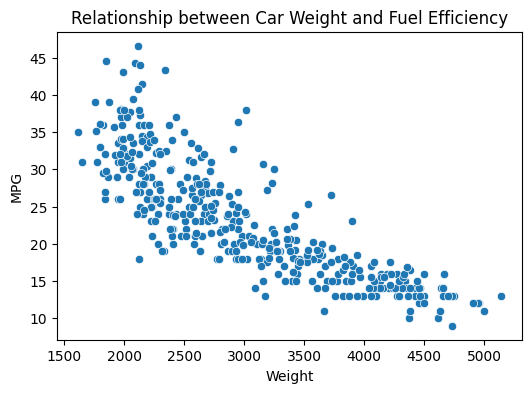

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(x="weight", y="mpg", data=df)

plt.title("Relationship between Car Weight and Fuel Efficiency")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.show()

Чем тяжелее машина, тем меньше расход топлива (mpg)

In [6]:
# считаем коэффициенты корреляции между weight и mpg

pearson_corr = df["weight"].corr(df["mpg"], method="pearson")
spearman_corr = df["weight"].corr(df["mpg"], method="spearman")
kendall_corr = df["weight"].corr(df["mpg"], method="kendall")

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)
print("Kendall correlation:", kendall_corr)

Pearson correlation: -0.8322442148315753
Spearman correlation: -0.8755851198739869
Kendall correlation: -0.6942430506594828


Чем больше вес, тем меньше mpg

Pearson -0.83  сильная отрицательная линейная связь

Spearman -0.88  очень сильная монотонная связь

Kendall -0.69  тоже сильная отрицательная связь

Следовательно, тяжелые автомобили потребляют больше топлива

In [7]:
from scipy.stats import pearsonr, spearmanr, kendalltau

# Pearson
pearson_r, pearson_p = pearsonr(df["weight"], df["mpg"])

# Spearman
spearman_r, spearman_p = spearmanr(df["weight"], df["mpg"])

# Kendall
kendall_r, kendall_p = kendalltau(df["weight"], df["mpg"])

print("Pearson p-value:", pearson_p)
print("Spearman p-value:", spearman_p)
print("Kendall p-value:", kendall_p)

Pearson p-value: 6.01529605143857e-102
Spearman p-value: 2.662377938025222e-125
Kendall p-value: 5.80848870652623e-92


p-value < 0.05  корреляция статистически значима

p-value ≥ 0.05  корреляция может быть случайной

H0: корреляции нет

H1: корреляция существует


если p-value < 0.05 → отвергаем H0


0.000000000000... << 0.05


Следовательно, корреляция статистически значима.

В ходе корреляционного анализа обнаружена сильная отрицательная связь
между весом автомобиля (weight) и топливной эффективностью (mpg).

Коэффициент Пирсона: -0.83

Коэффициент Спирмена: -0.88

Коэффициент Кендалла: -0.69


Все p-value значительно меньше 0.05, что говорит о статистической значимости
обнаруженной зависимости.

Таким образом, увеличение веса автомобиля связано со снижением
топливной эффективности.

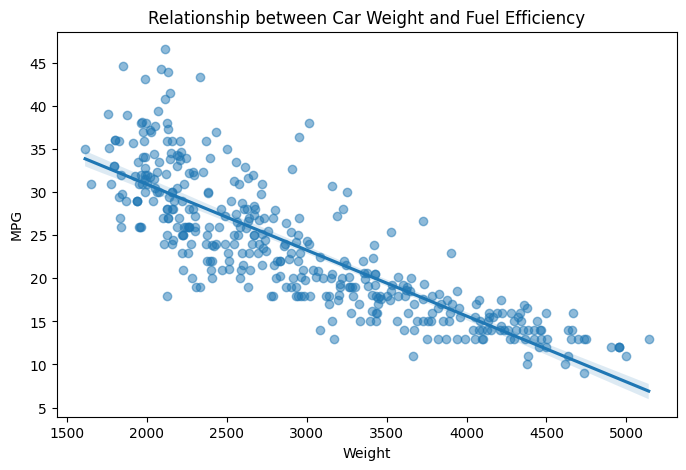

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.regplot(
    x="weight",
    y="mpg",
    data=df,
    scatter_kws={"alpha":0.5}
)

plt.title("Relationship between Car Weight and Fuel Efficiency")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.savefig("weight_vs_mpg_regression.png")

plt.show()